## GSet Maxcut

In [1]:
from pathlib import Path
import torch
import numpy as np

In [6]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

Using device: mps


### LOAD A GSET FILE

In [7]:
def load_gset_dense(path, device="mps", dtype=torch.float32, index_start=1):
    path = Path(path)

    with path.open("r") as f:
        first = f.readline().strip().split()
        if len(first) != 2:
            raise ValueError(f"Bad first line in {path}: {first}")

        n, m = map(int, first)
        W = torch.zeros((n, n), dtype=dtype, device=device)

        edge_count = 0
        total_weight = 0.0

        for line_id, line in enumerate(f, start=2):
            parts = line.strip().split()
            if not parts:
                continue

            if len(parts) != 3:
                raise ValueError(f"Bad line {line_id} in {path}: {line}")

            i, j, w = parts
            i = int(i) - index_start
            j = int(j) - index_start
            w = float(w)

            if not (0 <= i < n and 0 <= j < n):
                raise IndexError(
                    f"Node index out of range at line {line_id}: "
                    f"i={i}, j={j}, n={n}"
                )

            W[i, j] = w
            W[j, i] = w

            edge_count += 1
            total_weight += w

    info = {
        "path": str(path),
        "n": n,
        "m_header": m,
        "m_loaded": edge_count,
        "total_weight_edges": total_weight,
        "W_sum": float(W.sum().detach().cpu().item()),
        "symmetric": bool(torch.allclose(W, W.T)),
        "diag_zero": bool(torch.allclose(torch.diag(W), torch.zeros(n, dtype=dtype, device=device))),
    }

    return W, info

In [8]:
from pathlib import Path

gset_path = Path("../data-gset/G1")
W, info = load_gset_dense(gset_path, device="cpu")

info

{'path': '../data-gset/G1',
 'n': 800,
 'm_header': 19176,
 'm_loaded': 19176,
 'total_weight_edges': 19176.0,
 'W_sum': 38352.0,
 'symmetric': True,
 'diag_zero': True}

### LOAD GSET VALIDATION file

In [9]:
from pathlib import Path
import pandas as pd

validation_path = Path("gset_validation.txt")

if not validation_path.exists():
    raise FileNotFoundError(
        f"Could not find {validation_path.resolve()}. "
        "Place gset_validation.txt in the same directory as this notebook."
    )

records = []

with validation_path.open("r") as f:
    for line_no, line in enumerate(f, start=1):
        line = line.strip()

        if not line or line.startswith("#"):
            continue

        parts = line.split()

        if len(parts) != 2:
            raise ValueError(
                f"Bad line {line_no}: {line!r}. "
                "Expected format: <gset_index> <best_known_cut>"
            )

        g_index = int(parts[0])
        best_known_cut = int(parts[1])

        records.append(
            {
                "g_index": g_index,
                "instance": f"G{g_index}",
                "best_known_cut": best_known_cut,
            }
        )

# Full validation table from file
gset_all_best_df = (
    pd.DataFrame(records)
    .sort_values("g_index")
    .reset_index(drop=True)
)

# Restrict benchmark scope to G1-G10 only
gset_g1_g10_df = (
    gset_all_best_df
    .query("1 <= g_index <= 10")
    .reset_index(drop=True)
)

# Safety check: make sure all G1-G10 entries exist
expected_instances = {f"G{i}" for i in range(1, 11)}
loaded_instances = set(gset_g1_g10_df["instance"])

missing = sorted(expected_instances - loaded_instances)

if missing:
    raise ValueError(
        f"Missing best-known values for: {missing}. "
        "Fix gset_validation.txt before benchmarking."
    )

# Lookup dictionary for later solver comparison
GSET_G1_G10_BEST = dict(
    zip(gset_g1_g10_df["instance"], gset_g1_g10_df["best_known_cut"])
)

print(f"Loaded full validation entries: {len(gset_all_best_df)}")
print(f"Active benchmark scope: G1-G10 only")
print()

display(gset_g1_g10_df)

Loaded full validation entries: 71
Active benchmark scope: G1-G10 only



,g_index,instance,best_known_cut
0,1,G1,11624
1,2,G2,11620
2,3,G3,11622
3,4,G4,11646
4,5,G5,11631
5,6,G6,2178
6,7,G7,2006
7,8,G8,2005
8,9,G9,2054
9,10,G10,2000


### Entropy!

In [10]:
def binary_entropy(p, eps=1e-12):
    """
    Mean-field Bernoulli entropy.
    p has shape [R, N] or [N].
    S(p) = - sum_i [p_i log p_i + (1-p_i) log(1-p_i)]
    Returns:
        shape [R] if p is [R, N]
        scalar if p is [N]
    """
    if p.dim() == 1:
        p = p.unsqueeze(0)
    p = p.clamp(eps, 1.0 - eps)
    S = -(
        p * torch.log(p)
        + (1.0 - p) * torch.log(1.0 - p)
    ).sum(dim=1)
    return S.squeeze()

### Average Maxcut Energy

1. Probability of an edge being cut $p_i(1-p_j) + (1-p_i)p_j$ which in matrix form should be $\sum p_i W_{i,j} (1-p_j)$
2. This cut is differentiable and training objective contributor expected cut.

In [11]:
def expected_cut(W, p):
    """
    Mean-field expected MaxCut value.

    W : dense symmetric adjacency matrix, shape [N, N]
    p : probability P(s_i = +1), shape [R, N] or [N]

    For symmetric dense W:
        E[C] = sum_{i,j} p_i W_ij (1 - p_j)

    This is differentiable and enters FEM.
    """
    if p.dim() == 1:
        p = p.unsqueeze(0)

    p = p.to(W.device)

    cut_exp = torch.einsum("ri,ij,rj->r", p, W, 1.0 - p)

    return cut_exp.squeeze()

### Discrete Cut value

Final calculation using hard assigned spins, $\frac{1}{4} \sum W_{i,j} (1-s_is_j)$. Factor 1/4 comes from (i) (1-sisj)/2 which is basically (1-$\delta$(si,sj)) and (ii) because of symmetricity of dense adjacency matrix

In [12]:
def discrete_cut(W, spins):
    """
    Actual hard MaxCut value after readout.

    spins : {-1, +1}, shape [R, N] or [N]

    For dense symmetric W:
        C(s) = 1/4 * sum_ij W_ij (1 - s_i s_j)
    """
    if spins.dim() == 1:
        spins = spins.unsqueeze(0)

    spins = spins.to(W.device).float()

    quad = torch.einsum("ri,ij,rj->r", spins, W, spins)
    cut = 0.25 * (W.sum() - quad)

    return cut.squeeze()

### Free energy calculation -> $F_{MF} = - ExpectedCut(p) - S(p)/beta$

In [13]:
def fem_free_energy_maxcut(W, h, beta):
    """
    Classical binary FEM free energy for MaxCut.

    h : local fields, shape [R, N]
    p : sigmoid(h)

    F = - ExpectedCut(p) - S(p)/beta

    Since S is positive entropy:
        F = -ExpectedCut + (1/beta) * sum p log p
    """
    p = torch.sigmoid(h)

    U = -expected_cut(W, p)
    S = binary_entropy(p)

    F = U - S / beta

    return F, {
        "p": p,
        "expected_cut": -U,
        "entropy": S,
        "internal_energy": U,
    }

### Beta schedule (inverse temperature)

In [14]:
from math import log
import torch

def make_beta_schedule(
    beta_min=2.0,
    beta_max=12500.0,
    N_steps=1000,
    kind="linear",
    device=None,
    dtype=torch.float32,
):

    if device is None:
        device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

    if N_steps < 2:
        raise ValueError("N_steps must be >= 2.")

    if beta_min <= 0 or beta_max <= 0:
        raise ValueError("beta_min and beta_max must be positive.")

    if beta_max <= beta_min:
        raise ValueError("beta_max must be larger than beta_min.")

    if kind == "linear":
        betas = torch.linspace(
            beta_min,
            beta_max,
            N_steps,
            device=device,
            dtype=dtype,
        )

    elif kind == "exponential":
        betas = torch.exp(
            torch.linspace(
                log(beta_min),
                log(beta_max),
                N_steps,
                device=device,
                dtype=dtype,
            )
        )

    else:
        raise ValueError("kind must be either 'linear' or 'exponential'.")

    return betas

### Sanity test 1 -> G1

In [16]:
try:
    from tqdm.auto import tqdm
except ImportError:
    tqdm = None

In [17]:
# ============================================================
# Vanilla FEM MaxCut optimizer loop for one Gset instance
# with live progress printing
# ============================================================

import time
import torch
import pandas as pd

# ----------------------------
# Hyperparameters
# ----------------------------
R = 128
N_steps = 1000
beta_min = 2.0
beta_max = 12500.0
lr = 0.01
seed = 0

print_every = 50   # print diagnostics every this many steps

torch.manual_seed(seed)

# Make sure W is on correct device
W = W.to(device=device, dtype=torch.float32)
N = W.shape[0]

# ----------------------------
# Initialize local fields
# ----------------------------
h = 1e-3 * torch.randn(R, N, device=device, dtype=torch.float32)
h.requires_grad_(True)

optimizer = torch.optim.Adam([h], lr=lr)

# ----------------------------
# Beta schedule
# ----------------------------
beta_schedule = make_beta_schedule(
    beta_min=beta_min,
    beta_max=beta_max,
    N_steps=N_steps,
    kind="linear",
    device=device,
    dtype=torch.float32,
)

# ----------------------------
# History container
# ----------------------------
history = []

start_time = time.time()

# Use tqdm progress bar if available
iterator = tqdm(
    enumerate(beta_schedule),
    total=N_steps,
    desc="Vanilla FEM annealing",
) if tqdm is not None else enumerate(beta_schedule)

print("Starting vanilla FEM optimization...")
print(f"N = {N}, replicas = {R}, steps = {N_steps}, device = {device}")
print(f"beta_min = {beta_min}, beta_max = {beta_max}, lr = {lr}")
print("-" * 100)

for step, beta in iterator:
    # ----------------------------
    # Free energy computation
    # ----------------------------
    F, aux = fem_free_energy_maxcut(W, h, beta)

    # Mean loss across replicas
    loss = F.mean()

    # ----------------------------
    # Autodiff gradient update
    # ----------------------------
    optimizer.zero_grad()
    loss.backward()

    # Optional: measure gradient norm before optimizer step
    grad_norm = h.grad.detach().norm().item()

    optimizer.step()

    # ----------------------------
    # Logging / live diagnostics
    # ----------------------------
    if step % print_every == 0 or step == N_steps - 1:
        with torch.no_grad():
            p = torch.sigmoid(h)

            # Soft training diagnostic
            exp_cuts = expected_cut(W, p)

            # Hard readout
            spins = torch.where(
                p >= 0.5,
                torch.ones_like(p),
                -torch.ones_like(p),
            )

            hard_cuts = discrete_cut(W, spins)

            row = {
                "step": step,
                "beta": float(beta.detach().cpu()),
                "loss_mean": float(loss.detach().cpu()),
                "expected_cut_mean": float(exp_cuts.mean().detach().cpu()),
                "expected_cut_max": float(exp_cuts.max().detach().cpu()),
                "entropy_mean": float(aux["entropy"].mean().detach().cpu()),
                "hard_cut_mean": float(hard_cuts.mean().detach().cpu()),
                "hard_cut_max": float(hard_cuts.max().detach().cpu()),
                "grad_norm": grad_norm,
            }

            history.append(row)

            # Plain print, because sometimes tqdm output is too emotionally unavailable
            print(
                f"step {step:04d}/{N_steps-1} | "
                f"beta={row['beta']:.3f} | "
                f"loss={row['loss_mean']:.3f} | "
                f"Ecut_mean={row['expected_cut_mean']:.3f} | "
                f"Ecut_max={row['expected_cut_max']:.3f} | "
                f"Hcut_max={row['hard_cut_max']:.3f} | "
                f"S_mean={row['entropy_mean']:.3f} | "
                f"grad={row['grad_norm']:.3e}",
                flush=True,
            )

            # Optional live tqdm postfix
            if tqdm is not None:
                iterator.set_postfix(
                    {
                        "beta": f"{row['beta']:.2e}",
                        "hard_best": f"{row['hard_cut_max']:.0f}",
                        "entropy": f"{row['entropy_mean']:.1f}",
                    }
                )

end_time = time.time()

Starting vanilla FEM optimization...
N = 800, replicas = 128, steps = 1000, device = mps
beta_min = 2.0, beta_max = 12500.0, lr = 0.01
----------------------------------------------------------------------------------------------------
step 0000/999 | beta=2.000 | loss=-9865.259 | Ecut_mean=9587.990 | Ecut_max=9588.008 | Hcut_max=9672.000 | S_mean=554.518 | grad=2.179e-03
step 0050/999 | beta=627.526 | loss=-9714.267 | Ecut_mean=9719.707 | Ecut_max=9733.641 | Hcut_max=11369.000 | S_mean=526.530 | grad=1.563e+00
step 0100/999 | beta=1253.051 | loss=-10148.436 | Ecut_mean=10157.679 | Ecut_max=10186.683 | Hcut_max=11406.000 | S_mean=423.236 | grad=2.405e+00
step 0150/999 | beta=1878.577 | loss=-10563.490 | Ecut_mean=10569.967 | Ecut_max=10619.037 | Hcut_max=11419.000 | S_mean=312.580 | grad=2.065e+00
step 0200/999 | beta=2504.102 | loss=-10822.826 | Ecut_mean=10826.637 | Ecut_max=10885.587 | Hcut_max=11420.000 | S_mean=234.312 | grad=1.556e+00
step 0250/999 | beta=3129.628 | loss=-10976.3

In [18]:
# ----------------------------
# Final readout
# ----------------------------
with torch.no_grad():
    p_final = torch.sigmoid(h)

    spins_final = torch.where(
        p_final >= 0.5,
        torch.ones_like(p_final),
        -torch.ones_like(p_final),
    )

    cut_final_all = discrete_cut(W, spins_final)

    best_idx = int(torch.argmax(cut_final_all).detach().cpu())
    best_cut = float(cut_final_all[best_idx].detach().cpu())
    best_spins = spins_final[best_idx].detach().cpu()
    best_p = p_final[best_idx].detach().cpu()

history_df = pd.DataFrame(history)

print("-" * 100)
print("Finished vanilla FEM run.")
print("Runtime seconds:", round(end_time - start_time, 4))
print("Best cut:", best_cut)
print("Best replica index:", best_idx)

display(history_df.tail())

----------------------------------------------------------------------------------------------------
Finished vanilla FEM run.
Runtime seconds: 6.3743
Best cut: 11446.0
Best replica index: 10


,step,beta,loss_mean,expected_cut_mean,expected_cut_max,entropy_mean,hard_cut_mean,hard_cut_max,grad_norm
16,800,10010.408203,-11311.519531,11311.651367,11383.736328,43.887871,11368.398438,11443.0,0.204026
17,850,10635.933594,-11317.850586,11317.963867,11389.763672,40.522850,11369.312500,11443.0,0.185069
18,900,11261.458984,-11323.305664,11323.404297,11395.369141,37.560551,11370.054688,11443.0,0.168900
19,950,11886.985352,-11328.056641,11328.142578,11400.533203,34.960957,11370.750000,11446.0,0.154689
20,999,12500.000000,-11332.142578,11332.217773,11404.753906,32.722427,11371.289062,11446.0,0.142341


In [19]:
instance = "G1"

best_known = GSET_G1_G10_BEST[instance]

gap = best_known - best_cut
accuracy = best_cut / best_known
percent_accuracy = 100 * accuracy

print("Instance:", instance)
print("Best-known cut:", best_known)
print("Your FEM best cut:", best_cut)
print("Gap:", gap)
print("Accuracy:", accuracy)
print("Percent accuracy:", percent_accuracy,"%")

Instance: G1
Best-known cut: 11624
Your FEM best cut: 11446.0
Gap: 178.0
Accuracy: 0.9846868547832072
Percent accuracy: 98.46868547832072 %


### G1-G10 validation

In [34]:
# ============================================================
# Vanilla FEM sweep: G1 to G10
# ============================================================

import time
import torch
import pandas as pd
from pathlib import Path

DATA_GSET_DIR = Path("../data-gset")

def run_vanilla_fem_single_gset(
    instance,
    R=128,
    N_steps=1000,
    beta_min=2.0,
    beta_max=12500.0,
    lr=0.01,
    seed=0,
    schedule_kind="linear",
    print_every=100,
    device=device,
):
    """
    Run vanilla binary FEM on one Gset instance.

    Uses:
        F = -ExpectedCut(p) - S(p)/beta
        p = sigmoid(h)

    Returns:
        result_row : dict
        history_df : pandas DataFrame
    """

    # ----------------------------
    # Load graph
    # ----------------------------
    gset_path = DATA_GSET_DIR / instance

    if not gset_path.exists():
        raise FileNotFoundError(
            f"Could not find {gset_path.resolve()}. "
            f"Check filename for {instance}."
        )

    W, info = load_gset_dense(gset_path, device=device)
    W = W.to(device=device, dtype=torch.float32)

    N = W.shape[0]

    # ----------------------------
    # Initialize fields
    # ----------------------------
    torch.manual_seed(seed)

    h = 1e-3 * torch.randn(R, N, device=device, dtype=torch.float32)
    h.requires_grad_(True)

    optimizer = torch.optim.Adam([h], lr=lr)

    beta_schedule = make_beta_schedule(
        beta_min=beta_min,
        beta_max=beta_max,
        N_steps=N_steps,
        kind=schedule_kind,
        device=device,
        dtype=torch.float32,
    )

    history = []

    print("=" * 100)
    print(f"Running {instance}")
    print(f"N={N}, edges={info['m_loaded']}, replicas={R}, steps={N_steps}, device={device}")
    print(f"beta_min={beta_min}, beta_max={beta_max}, schedule={schedule_kind}, lr={lr}, seed={seed}")
    print("=" * 100)

    start_time = time.time()

    iterator = tqdm(
        enumerate(beta_schedule),
        total=N_steps,
        desc=f"{instance} vanilla FEM",
    ) if tqdm is not None else enumerate(beta_schedule)

    # ----------------------------
    # Optimization loop
    # ----------------------------
    for step, beta in iterator:
        F, aux = fem_free_energy_maxcut(W, h, beta)
        loss = F.mean()

        optimizer.zero_grad()
        loss.backward()
        grad_norm = float(h.grad.detach().norm().cpu())
        optimizer.step()

        if step % print_every == 0 or step == N_steps - 1:
            with torch.no_grad():
                p = torch.sigmoid(h)

                exp_cuts = expected_cut(W, p)

                spins = torch.where(
                    p >= 0.5,
                    torch.ones_like(p),
                    -torch.ones_like(p),
                )

                hard_cuts = discrete_cut(W, spins)

                row = {
                    "instance": instance,
                    "step": step,
                    "beta": float(beta.detach().cpu()),
                    "loss_mean": float(loss.detach().cpu()),
                    "expected_cut_mean": float(exp_cuts.mean().detach().cpu()),
                    "expected_cut_max": float(exp_cuts.max().detach().cpu()),
                    "entropy_mean": float(aux["entropy"].mean().detach().cpu()),
                    "hard_cut_mean": float(hard_cuts.mean().detach().cpu()),
                    "hard_cut_max": float(hard_cuts.max().detach().cpu()),
                    "grad_norm": grad_norm,
                }

                history.append(row)

                print(
                    f"{instance} | "
                    f"step {step:04d}/{N_steps-1} | "
                    f"beta={row['beta']:.3f} | "
                    f"Hcut_max={row['hard_cut_max']:.1f} | "
                    f"Ecut_max={row['expected_cut_max']:.1f} | "
                    f"S_mean={row['entropy_mean']:.2f} | "
                    f"grad={row['grad_norm']:.3e}",
                    flush=True,
                )

                if tqdm is not None:
                    iterator.set_postfix(
                        {
                            "hard_best": f"{row['hard_cut_max']:.0f}",
                            "entropy": f"{row['entropy_mean']:.1f}",
                        }
                    )

    end_time = time.time()
    runtime_sec = end_time - start_time

    # ----------------------------
    # Final readout
    # ----------------------------
    with torch.no_grad():
        p_final = torch.sigmoid(h)

        spins_final = torch.where(
            p_final >= 0.5,
            torch.ones_like(p_final),
            -torch.ones_like(p_final),
        )

        cut_final_all = discrete_cut(W, spins_final)

        best_idx = int(torch.argmax(cut_final_all).detach().cpu())
        best_cut = float(cut_final_all[best_idx].detach().cpu())

    best_known = GSET_BEST_KNOWN_ALL[instance]
    gap = best_known - best_cut
    accuracy = best_cut / best_known
    percent_accuracy = 100.0 * accuracy

    result_row = {
        "instance": instance,
        "N": N,
        "edges": info["m_loaded"],
        "best_known_cut": best_known,
        "vanilla_fem_best_cut": best_cut,
        "gap": gap,
        "accuracy": accuracy,
        "percent_accuracy": percent_accuracy,
        "runtime_sec": runtime_sec,
        "best_replica": best_idx,
        "R": R,
        "N_steps": N_steps,
        "beta_min": beta_min,
        "beta_max": beta_max,
        "schedule_kind": schedule_kind,
        "lr": lr,
        "seed": seed,
    }

    history_df = pd.DataFrame(history)

    print("-" * 100)
    print(f"Finished {instance}")
    print(f"Best known: {best_known}")
    print(f"Vanilla FEM best cut: {best_cut}")
    print(f"Gap: {gap}")
    print(f"Accuracy: {percent_accuracy:.4f}%")
    print(f"Runtime: {runtime_sec:.3f} sec")
    print("-" * 100)

    return result_row, history_df

In [22]:
# ============================================================
# Run G1-G10 vanilla FEM benchmark
# ============================================================

instances = [f"G{i}" for i in range(1, 11)]

all_results = []
all_histories = {}

for instance in instances:
    result_row, history_df = run_vanilla_fem_single_gset(
        instance=instance,
        R=128,
        N_steps=1000,
        beta_min=2.0,
        beta_max=12500.0,
        lr=0.01,
        seed=0,
        schedule_kind="linear",
        print_every=100,
        device=device,
    )

    all_results.append(result_row)
    all_histories[instance] = history_df

    # Save partial result after every graph, because kernels die like cowards.
    partial_df = pd.DataFrame(all_results)
    partial_df.to_csv("vanilla_fem_g1_g10_partial_results.csv", index=False)

vanilla_g1_g10_results_df = pd.DataFrame(all_results)

vanilla_g1_g10_results_df.to_csv(
    "vanilla_fem_g1_g10_results.csv",
    index=False,
)

print("Finished G1-G10 sweep.")

Running G1
N=800, edges=19176, replicas=128, steps=1000, device=mps
beta_min=2.0, beta_max=12500.0, schedule=linear, lr=0.01, seed=0
G1 | step 0000/999 | beta=2.000 | Hcut_max=9672.0 | Ecut_max=9588.0 | S_mean=554.52 | grad=2.179e-03
G1 | step 0100/999 | beta=1253.051 | Hcut_max=11406.0 | Ecut_max=10186.7 | S_mean=423.24 | grad=2.405e+00
G1 | step 0200/999 | beta=2504.102 | Hcut_max=11420.0 | Ecut_max=10885.6 | S_mean=234.31 | grad=1.556e+00
G1 | step 0300/999 | beta=3755.153 | Hcut_max=11436.0 | Ecut_max=11146.3 | S_mean=148.01 | grad=9.131e-01
G1 | step 0400/999 | beta=5006.204 | Hcut_max=11441.0 | Ecut_max=11257.5 | S_mean=104.87 | grad=5.983e-01
G1 | step 0500/999 | beta=6257.255 | Hcut_max=11442.0 | Ecut_max=11314.4 | S_mean=79.70 | grad=4.258e-01
G1 | step 0600/999 | beta=7508.306 | Hcut_max=11442.0 | Ecut_max=11347.6 | S_mean=63.45 | grad=3.209e-01
G1 | step 0700/999 | beta=8759.357 | Hcut_max=11442.0 | Ecut_max=11369.0 | S_mean=52.15 | grad=2.519e-01
G1 | step 0800/999 | beta=1

In [23]:
display(vanilla_g1_g10_results_df)

,instance,N,edges,best_known_cut,vanilla_fem_best_cut,gap,accuracy,percent_accuracy,runtime_sec,best_replica,R,N_steps,beta_min,beta_max,schedule_kind,lr,seed
0,G1,800,19176,11624,11446.0,178.0,0.984687,98.468685,4.368305,10,128,1000,2.0,12500.0,linear,0.01,0
1,G2,800,19176,11620,11435.0,185.0,0.984079,98.407917,4.299664,55,128,1000,2.0,12500.0,linear,0.01,0
2,G3,800,19176,11622,11443.0,179.0,0.984598,98.459818,4.356321,14,128,1000,2.0,12500.0,linear,0.01,0
3,G4,800,19176,11646,11503.0,143.0,0.987721,98.772111,4.275009,75,128,1000,2.0,12500.0,linear,0.01,0
4,G5,800,19176,11631,11450.0,181.0,0.984438,98.443814,4.161925,106,128,1000,2.0,12500.0,linear,0.01,0
5,G6,800,19176,2178,1978.0,200.0,0.908173,90.817264,4.394011,6,128,1000,2.0,12500.0,linear,0.01,0
6,G7,800,19176,2006,1822.0,184.0,0.908275,90.827517,4.333263,110,128,1000,2.0,12500.0,linear,0.01,0
7,G8,800,19176,2005,1856.0,149.0,0.925686,92.568579,4.411136,25,128,1000,2.0,12500.0,linear,0.01,0
8,G9,800,19176,2054,1840.0,214.0,0.895813,89.581305,4.523476,92,128,1000,2.0,12500.0,linear,0.01,0
9,G10,800,19176,2000,1819.0,181.0,0.909500,90.950000,4.260001,55,128,1000,2.0,12500.0,linear,0.01,0


## Problem region testing G35-G42

Testing batches : 

1. Batch 1 : G1 G10
2. Batch 2 : G11 G13
3. Batch 3 : G14 G21
4. Batch 4 : G22 G31
5. Batch 5 : G32 G34
6. Batch 6 : G35 G42 (problem batch)
7. Batch 7 : G43 G47
8. Batch 8 : G48 G50
9. Batch 9 : G51 G54

In [32]:
# ============================================================
# Full Gset best-known lookup from validation dataframe
# ============================================================

GSET_BEST_KNOWN_ALL = dict(
    zip(gset_all_best_df["instance"], gset_all_best_df["best_known_cut"])
)

print("Loaded best-known values:", len(GSET_BEST_KNOWN_ALL))

Loaded best-known values: 71


### Batch 6

In [35]:
# ============================================================
# Batch 6: Vanilla FEM on G35-G42
# ============================================================

batch_id = 6
instances_batch6 = [f"G{i}" for i in range(35, 43)]

batch6_results = []
batch6_histories = {}

for instance in instances_batch6:
    result_row, history_df = run_vanilla_fem_single_gset(
        instance=instance,
        R=128,
        N_steps=1000,
        beta_min=2.0,
        beta_max=12500.0,
        lr=0.01,
        seed=0,
        schedule_kind="linear",
        print_every=100,
        device=device,
    )

    batch6_results.append(result_row)
    batch6_histories[instance] = history_df

    # Save partial dataframe after every graph
    partial_df = pd.DataFrame(batch6_results)
    partial_df.to_csv("run#6_vanilla_fem_G35-G42_partial.csv", index=False)

batch6_results_df = pd.DataFrame(batch6_results)

display(batch6_results_df)

batch6_results_df.to_csv("run#6_vanilla_fem_G35-G42_full.csv", index=False)

print("Finished Batch 6: G35-G42")

Running G35
N=2000, edges=11778, replicas=128, steps=1000, device=mps
beta_min=2.0, beta_max=12500.0, schedule=linear, lr=0.01, seed=0
G35 | step 0000/999 | beta=2.000 | Hcut_max=4948.0 | Ecut_max=5889.0 | S_mean=1386.29 | grad=1.765e-03
G35 | step 0100/999 | beta=1253.051 | Hcut_max=7479.0 | Ecut_max=6414.7 | S_mean=1060.74 | grad=1.725e+00
G35 | step 0200/999 | beta=2504.102 | Hcut_max=7493.0 | Ecut_max=7026.1 | S_mean=601.33 | grad=1.110e+00
G35 | step 0300/999 | beta=3755.153 | Hcut_max=7505.0 | Ecut_max=7252.9 | S_mean=388.35 | grad=6.496e-01
G35 | step 0400/999 | beta=5006.204 | Hcut_max=7515.0 | Ecut_max=7354.1 | S_mean=279.90 | grad=4.254e-01
G35 | step 0500/999 | beta=6257.255 | Hcut_max=7519.0 | Ecut_max=7407.3 | S_mean=216.17 | grad=3.029e-01
G35 | step 0600/999 | beta=7508.306 | Hcut_max=7520.0 | Ecut_max=7437.5 | S_mean=174.78 | grad=2.279e-01
G35 | step 0700/999 | beta=8759.357 | Hcut_max=7521.0 | Ecut_max=7456.9 | S_mean=146.05 | grad=1.787e-01
G35 | step 0800/999 | beta

,instance,N,edges,best_known_cut,vanilla_fem_best_cut,gap,accuracy,percent_accuracy,runtime_sec,best_replica,R,N_steps,beta_min,beta_max,schedule_kind,lr,seed
0,G35,2000,11778,7687,7523.0,164.0,0.978665,97.866528,8.681002,127,128,1000,2.0,12500.0,linear,0.01,0
1,G36,2000,11766,7680,7515.0,165.0,0.978516,97.851562,8.722572,15,128,1000,2.0,12500.0,linear,0.01,0
2,G37,2000,11785,7691,7520.0,171.0,0.977766,97.776622,8.150533,3,128,1000,2.0,12500.0,linear,0.01,0
3,G38,2000,11779,7688,7514.0,174.0,0.977367,97.736733,8.672927,29,128,1000,2.0,12500.0,linear,0.01,0
4,G39,2000,11778,2408,2188.0,220.0,0.908638,90.863787,8.836483,67,128,1000,2.0,12500.0,linear,0.01,0
5,G40,2000,11766,2400,2183.0,217.0,0.909583,90.958333,8.739482,86,128,1000,2.0,12500.0,linear,0.01,0
6,G41,2000,11785,2405,2193.0,212.0,0.911850,91.185031,8.396403,50,128,1000,2.0,12500.0,linear,0.01,0
7,G42,2000,11779,2481,2273.0,208.0,0.916163,91.616284,8.138303,74,128,1000,2.0,12500.0,linear,0.01,0


Finished Batch 6: G35-G42


In [36]:
display(batch6_results_df)

,instance,N,edges,best_known_cut,vanilla_fem_best_cut,gap,accuracy,percent_accuracy,runtime_sec,best_replica,R,N_steps,beta_min,beta_max,schedule_kind,lr,seed
0,G35,2000,11778,7687,7523.0,164.0,0.978665,97.866528,8.681002,127,128,1000,2.0,12500.0,linear,0.01,0
1,G36,2000,11766,7680,7515.0,165.0,0.978516,97.851562,8.722572,15,128,1000,2.0,12500.0,linear,0.01,0
2,G37,2000,11785,7691,7520.0,171.0,0.977766,97.776622,8.150533,3,128,1000,2.0,12500.0,linear,0.01,0
3,G38,2000,11779,7688,7514.0,174.0,0.977367,97.736733,8.672927,29,128,1000,2.0,12500.0,linear,0.01,0
4,G39,2000,11778,2408,2188.0,220.0,0.908638,90.863787,8.836483,67,128,1000,2.0,12500.0,linear,0.01,0
5,G40,2000,11766,2400,2183.0,217.0,0.909583,90.958333,8.739482,86,128,1000,2.0,12500.0,linear,0.01,0
6,G41,2000,11785,2405,2193.0,212.0,0.911850,91.185031,8.396403,50,128,1000,2.0,12500.0,linear,0.01,0
7,G42,2000,11779,2481,2273.0,208.0,0.916163,91.616284,8.138303,74,128,1000,2.0,12500.0,linear,0.01,0


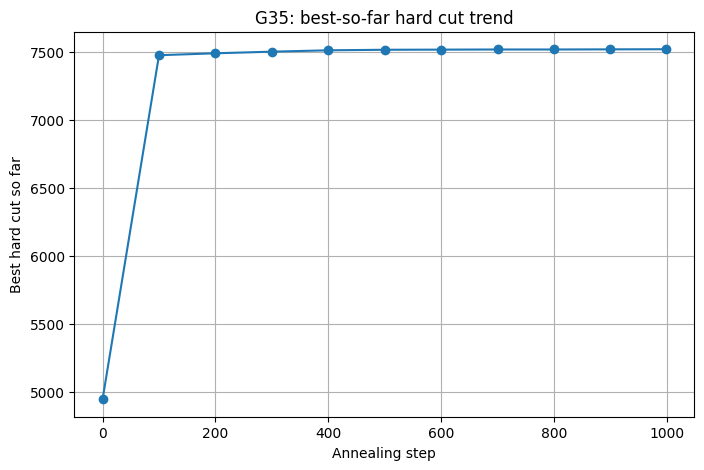

In [38]:
import matplotlib.pyplot as plt

instance = "G35"
hist = batch6_histories[instance].copy()

hist["hard_cut_best_so_far"] = hist["hard_cut_max"].cummax()

plt.figure(figsize=(8, 5))
plt.plot(hist["step"], hist["hard_cut_best_so_far"], marker="o")

plt.xlabel("Annealing step")
plt.ylabel("Best hard cut so far")
plt.title(f"{instance}: best-so-far hard cut trend")
plt.grid(True)
plt.show()

Improvements:

1. Increase replica number, N_steps.
2. Try for exponential beta anneal.
3. Try all batches.
4. Tabulate top 10 replica candidates
5. Use parameters by prof_code

But first retrieve all results for the naive run!

#### Remaining batches

In [43]:
# ============================================================
# FEM paper-style Gset batches
# ============================================================

GSET_BATCHES = {
    1: [f"G{i}" for i in range(1, 11)],    # G1-G10
    2: [f"G{i}" for i in range(11, 14)],   # G11-G13
    3: [f"G{i}" for i in range(14, 22)],   # G14-G21
    4: [f"G{i}" for i in range(22, 32)],   # G22-G31
    5: [f"G{i}" for i in range(32, 35)],   # G32-G34
    6: [f"G{i}" for i in range(35, 43)],   # G35-G42 problem batch
    7: [f"G{i}" for i in range(43, 48)],   # G43-G47
    8: [f"G{i}" for i in range(48, 51)],   # G48-G50
    9: [f"G{i}" for i in range(51, 55)],   # G51-G54
}

for batch_id, instances in GSET_BATCHES.items():
    print(f"Batch {batch_id}: {instances[0]}-{instances[-1]} | {instances}")

Batch 1: G1-G10 | ['G1', 'G2', 'G3', 'G4', 'G5', 'G6', 'G7', 'G8', 'G9', 'G10']
Batch 2: G11-G13 | ['G11', 'G12', 'G13']
Batch 3: G14-G21 | ['G14', 'G15', 'G16', 'G17', 'G18', 'G19', 'G20', 'G21']
Batch 4: G22-G31 | ['G22', 'G23', 'G24', 'G25', 'G26', 'G27', 'G28', 'G29', 'G30', 'G31']
Batch 5: G32-G34 | ['G32', 'G33', 'G34']
Batch 6: G35-G42 | ['G35', 'G36', 'G37', 'G38', 'G39', 'G40', 'G41', 'G42']
Batch 7: G43-G47 | ['G43', 'G44', 'G45', 'G46', 'G47']
Batch 8: G48-G50 | ['G48', 'G49', 'G50']
Batch 9: G51-G54 | ['G51', 'G52', 'G53', 'G54']


In [44]:
from pathlib import Path
from IPython.display import FileLink, display

def save_vanilla_batch_txt(results_df, batch_id, filename=None, save_downloads=True):
    """
    Save batch result dataframe as txt using the agreed format:
    {gset#} {nodes#} {cut value} {best value} {gap} {% accuracy} {tts in seconds}
    """

    if filename is None:
        filename = f"run#{batch_id}_vanilla_fem.txt"

    out_df = results_df.rename(
        columns={
            "instance": "gset#",
            "N": "nodes#",
            "vanilla_fem_best_cut": "cut_value",
            "best_known_cut": "best_value",
            "gap": "gap",
            "percent_accuracy": "%_accuracy",
            "runtime_sec": "tts_seconds",
        }
    )[
        [
            "gset#",
            "nodes#",
            "cut_value",
            "best_value",
            "gap",
            "%_accuracy",
            "tts_seconds",
        ]
    ].copy()

    out_df["cut_value"] = out_df["cut_value"].round(0).astype(int)
    out_df["best_value"] = out_df["best_value"].round(0).astype(int)
    out_df["gap"] = out_df["gap"].round(0).astype(int)
    out_df["%_accuracy"] = out_df["%_accuracy"].round(4)
    out_df["tts_seconds"] = out_df["tts_seconds"].round(4)

    output_path = Path.cwd() / filename

    out_df.to_csv(
        output_path,
        sep=" ",
        index=False,
    )

    print(f"Saved batch {batch_id} txt:")
    print(output_path.resolve())
    display(FileLink(str(output_path)))

    if save_downloads:
        downloads_path = Path.home() / "Downloads" / filename

        out_df.to_csv(
            downloads_path,
            sep=" ",
            index=False,
        )

        print("Also saved to Downloads:")
        print(downloads_path.resolve())
        display(FileLink(str(downloads_path)))

    return out_df

In [48]:
# ============================================================
# Naive vanilla FEM sweep for batches 2-9, skipping batch 6
# ============================================================

NAIVE_PARAMS = {
    "R": 128,
    "N_steps": 1000,
    "beta_min": 2.0,
    "beta_max": 12500.0,
    "lr": 0.01,
    "seed": 0,
    "schedule_kind": "linear",
    "print_every": 100,
    "device": device,
}

batches_to_run = [2, 3, 4, 5, 7, 8, 9]  # skip 1 and 6 because already done

batch_results_dfs = {}
batch_histories = {}

for batch_id in batches_to_run:
    instances = GSET_BATCHES[batch_id]

    print("\n" + "#" * 110)
    print(f"STARTING BATCH {batch_id}: {instances[0]} to {instances[-1]}")
    print("#" * 110)

    current_batch_results = []
    current_batch_histories = {}

    for instance in instances:
        result_row, history_df = run_vanilla_fem_single_gset(
            instance=instance,
            **NAIVE_PARAMS,
        )

        result_row["batch"] = batch_id

        current_batch_results.append(result_row)
        current_batch_histories[instance] = history_df

        # Save partial result after each graph
        partial_df = pd.DataFrame(current_batch_results)

        partial_csv_path = Path.cwd() / f"run#{batch_id}_vanilla_fem_partial.csv"
        partial_df.to_csv(partial_csv_path, index=False)

        print(f"Partial CSV saved: {partial_csv_path.resolve()}")

    batch_df = pd.DataFrame(current_batch_results)

    # Save full CSV for this batch
    full_csv_path = Path.cwd() / f"run#{batch_id}_vanilla_fem_full.csv"
    batch_df.to_csv(full_csv_path, index=False)

    print(f"\nFinished Batch {batch_id}")
    print(f"Full CSV saved: {full_csv_path.resolve()}")

    display(batch_df)

    # Save txt in agreed format
    save_vanilla_batch_txt(
        results_df=batch_df,
        batch_id=batch_id,
        filename=f"run#{batch_id}_vanilla_fem.txt",
        save_downloads=True,
    )

    batch_results_dfs[batch_id] = batch_df
    batch_histories[batch_id] = current_batch_histories


##############################################################################################################
STARTING BATCH 2: G11 to G13
##############################################################################################################
Running G11
N=800, edges=1600, replicas=128, steps=1000, device=mps
beta_min=2.0, beta_max=12500.0, schedule=linear, lr=0.01, seed=0
G11 | step 0000/999 | beta=2.000 | Hcut_max=-138.0 | Ecut_max=17.0 | S_mean=554.52 | grad=6.990e-04
G11 | step 0100/999 | beta=1253.051 | Hcut_max=512.0 | Ecut_max=182.7 | S_mean=424.10 | grad=6.510e-01
G11 | step 0200/999 | beta=2504.102 | Hcut_max=516.0 | Ecut_max=371.9 | S_mean=245.06 | grad=4.194e-01
G11 | step 0300/999 | beta=3755.153 | Hcut_max=518.0 | Ecut_max=441.2 | S_mean=160.19 | grad=2.474e-01
G11 | step 0400/999 | beta=5006.204 | Hcut_max=522.0 | Ecut_max=471.5 | S_mean=116.54 | grad=1.643e-01
G11 | step 0500/999 | beta=6257.255 | Hcut_max=522.0 | Ecut_max=487.8 | S_mean=91.26 | grad=1.170e-01
G

,instance,N,edges,best_known_cut,vanilla_fem_best_cut,gap,accuracy,percent_accuracy,runtime_sec,best_replica,R,N_steps,beta_min,beta_max,schedule_kind,lr,seed,batch
0,G11,800,1600,564,526.0,38.0,0.932624,93.262411,4.245101,52,128,1000,2.0,12500.0,linear,0.01,0,2
1,G12,800,1600,556,520.0,36.0,0.935252,93.525180,4.228104,126,128,1000,2.0,12500.0,linear,0.01,0,2
2,G13,800,1600,582,542.0,40.0,0.931271,93.127148,4.163056,28,128,1000,2.0,12500.0,linear,0.01,0,2


Saved batch 2 txt:
/Users/ronit/Desktop/QeFEM/main/jupyter/run#2_vanilla_fem.txt


/Users/ronit/Desktop/QeFEM/main/jupyter/run#2_vanilla_fem.txt

Also saved to Downloads:
/Users/ronit/Downloads/run#2_vanilla_fem.txt


...

,instance,N,edges,best_known_cut,vanilla_fem_best_cut,gap,accuracy,percent_accuracy,runtime_sec,best_replica,R,N_steps,beta_min,beta_max,schedule_kind,lr,seed,batch
0,G51,1000,5909,3848,3779.0,69.0,0.982069,98.206861,4.854330,34,128,1000,2.0,12500.0,linear,0.01,0,9
1,G52,1000,5916,3851,3779.0,72.0,0.981304,98.130356,5.070261,1,128,1000,2.0,12500.0,linear,0.01,0,9
2,G53,1000,5914,3850,3778.0,72.0,0.981299,98.129870,5.002833,57,128,1000,2.0,12500.0,linear,0.01,0,9
3,G54,1000,5916,3852,3778.0,74.0,0.980789,98.078920,4.496582,112,128,1000,2.0,12500.0,linear,0.01,0,9


Saved batch 9 txt:
/Users/ronit/Desktop/QeFEM/main/jupyter/run#9_vanilla_fem.txt


/Users/ronit/Desktop/QeFEM/main/jupyter/run#9_vanilla_fem.txt

Also saved to Downloads:
/Users/ronit/Downloads/run#9_vanilla_fem.txt


/Users/ronit/Downloads/run#9_vanilla_fem.txt

In [52]:
# ============================================================
# Register already-done batches 1 and 6 into the same dictionary
# ============================================================

# Batch 1: G1-G10
batch1_df = vanilla_g1_g10_results_df.copy()
batch1_df["batch"] = 1
batch_results_dfs[1] = batch1_df

# Batch 6: G35-G42
batch6_df = batch6_results_df.copy()
batch6_df["batch"] = 6
batch_results_dfs[6] = batch6_df

print("Registered Batch 1 and Batch 6.")
print("Available batch result keys:", sorted(batch_results_dfs.keys()))

Registered Batch 1 and Batch 6.
Available batch result keys: [1, 2, 3, 4, 5, 6, 7, 8, 9]


In [53]:
# ============================================================
# Register already-done batches 1 and 6 into the same dictionary
# ============================================================

# Batch 1: G1-G10
batch1_df = vanilla_g1_g10_results_df.copy()
batch1_df["batch"] = 1
batch_results_dfs[1] = batch1_df

# Batch 6: G35-G42
batch6_df = batch6_results_df.copy()
batch6_df["batch"] = 6
batch_results_dfs[6] = batch6_df

print("Registered Batch 1 and Batch 6.")
print("Available batch result keys:", sorted(batch_results_dfs.keys()))

Registered Batch 1 and Batch 6.
Available batch result keys: [1, 2, 3, 4, 5, 6, 7, 8, 9]


In [54]:
# ============================================================
# Compile cumulative naive vanilla FEM results: G1-G54
# ============================================================

all_batch_ids = sorted(batch_results_dfs.keys())

full_vanilla_g1_g54_df = pd.concat(
    [batch_results_dfs[batch_id] for batch_id in all_batch_ids],
    ignore_index=True,
)

# Sort naturally by G index
full_vanilla_g1_g54_df["g_index"] = (
    full_vanilla_g1_g54_df["instance"]
    .str.replace("G", "", regex=False)
    .astype(int)
)

full_vanilla_g1_g54_df = (
    full_vanilla_g1_g54_df
    .sort_values("g_index")
    .reset_index(drop=True)
)

# Reorder useful columns
preferred_cols = [
    "batch",
    "g_index",
    "instance",
    "N",
    "edges",
    "best_known_cut",
    "vanilla_fem_best_cut",
    "gap",
    "accuracy",
    "percent_accuracy",
    "runtime_sec",
    "best_replica",
    "R",
    "N_steps",
    "beta_min",
    "beta_max",
    "schedule_kind",
    "lr",
    "seed",
]

existing_preferred_cols = [
    col for col in preferred_cols
    if col in full_vanilla_g1_g54_df.columns
]

remaining_cols = [
    col for col in full_vanilla_g1_g54_df.columns
    if col not in existing_preferred_cols
]

full_vanilla_g1_g54_df = full_vanilla_g1_g54_df[
    existing_preferred_cols + remaining_cols
]

# Save cumulative CSV
full_csv_path = Path.cwd() / "naive_vanilla_fem_G1-G54_full_results.csv"
full_vanilla_g1_g54_df.to_csv(full_csv_path, index=False)

print("Saved cumulative CSV:")
print(full_csv_path.resolve())

Saved cumulative CSV:
/Users/ronit/Desktop/QeFEM/main/jupyter/naive_vanilla_fem_G1-G54_full_results.csv


In [55]:
display(full_vanilla_g1_g54_df)

,batch,g_index,instance,N,edges,best_known_cut,vanilla_fem_best_cut,gap,accuracy,percent_accuracy,runtime_sec,best_replica,R,N_steps,beta_min,beta_max,schedule_kind,lr,seed
0,1,1,G1,800,19176,11624,11446.0,178.0,0.984687,98.468685,4.368305,10,128,1000,2.0,12500.0,linear,0.01,0
1,1,2,G2,800,19176,11620,11435.0,185.0,0.984079,98.407917,4.299664,55,128,1000,2.0,12500.0,linear,0.01,0
2,1,3,G3,800,19176,11622,11443.0,179.0,0.984598,98.459818,4.356321,14,128,1000,2.0,12500.0,linear,0.01,0
3,1,4,G4,800,19176,11646,11503.0,143.0,0.987721,98.772111,4.275009,75,128,1000,2.0,12500.0,linear,0.01,0
4,1,5,G5,800,19176,11631,11450.0,181.0,0.984438,98.443814,4.161925,106,128,1000,2.0,12500.0,linear,0.01,0
5,1,6,G6,800,19176,2178,1978.0,200.0,0.908173,90.817264,4.394011,6,128,1000,2.0,12500.0,linear,0.01,0
6,1,7,G7,800,19176,2006,1822.0,184.0,0.908275,90.827517,4.333263,110,128,1000,2.0,12500.0,linear,0.01,0
7,1,8,G8,800,19176,2005,1856.0,149.0,0.925686,92.568579,4.411136,25,128,1000,2.0,12500.0,linear,0.01,0
8,1,9,G9,800,19176,2054,1840.0,214.0,0.895813,89.581305,4.523476,92,128,1000,2.0,12500.0,linear,0.01,0
9,1,10,G10,800,19176,2000,1819.0,181.0,0.909500,90.950000,4.260001,55,128,1000,2.0,12500.0,linear,0.01,0
